In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# LAB

In [3]:
from utils import logpdf_GAU_ND, vrow
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1,1)) * 1.0
C = np.ones((1,1)) * 2.0

Y = np.exp(logpdf_GAU_ND(vrow(XPlot), m, C))

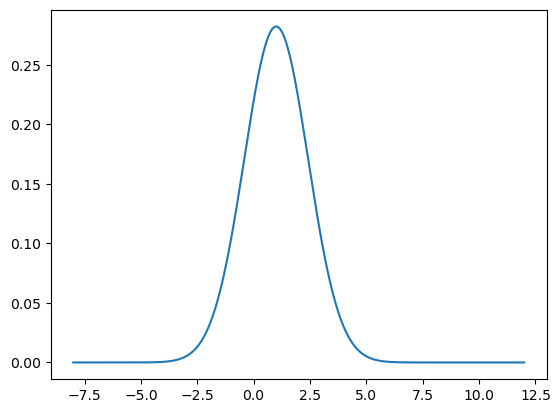

In [4]:
plt.figure()
plt.plot(XPlot.ravel(), Y.ravel())
plt.show()


In [5]:
from utils import vrow, logpdf_GAU_ND

pdfSol = np.load('../data/llGAU.npy')
pdfGau = logpdf_GAU_ND(vrow(XPlot), m, C)
print(np.abs(pdfSol - pdfGau).max())


0.0


In [6]:
XND = np.load('../data/XND.npy')
mu = np.load('../data/muND.npy')
C = np.load('../data/CND.npy')
pdfSol = np.load('../data/llND.npy')
pdfGau = logpdf_GAU_ND(XND, mu, C)
print(np.abs(pdfSol - pdfGau).max())

0.0


In [ ]:
from utils import loglikelihood, vcol, get_cov

XND = np.load('../data/XND.npy')
m_ML = vcol(XND.mean(1))
C_ML = get_cov(XND)

ll = loglikelihood(XND, m_ML, C_ML)

print(ll)

-270.70478023795044


-23227.07765460272


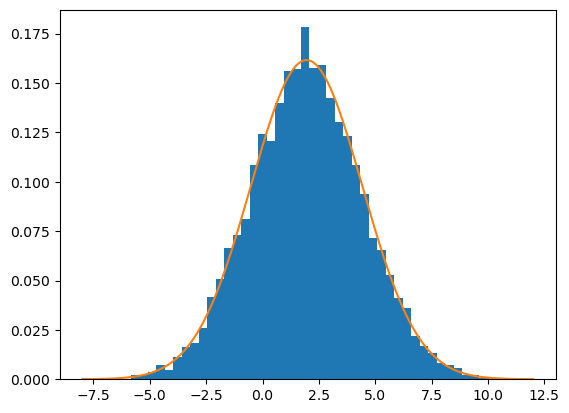

In [18]:
from utils import logpdf_GAU_ND, loglikelihood, vcol, vrow, get_cov

X1D = np.load('../data/X1D.npy')
m_ML = vcol(X1D.mean(1))
C_ML = get_cov(X1D)

ll = loglikelihood(X1D, m_ML, C_ML)

plt.figure()
plt.hist(X1D.ravel(), bins=50, density=True)
XPlot = np.linspace(-8, 12, 1000)
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m_ML, C_ML)))

print(ll)

# Project

In [19]:
PROJECT_FILE = "../data/trainData.txt"

In [20]:
from utils import load_data
D, L, labels = load_data(PROJECT_FILE)
feature_names = [f'F{i}' for i in range(0, D.shape[0])]
L = L.astype(int)
labels = [0, 1]

0 | F0 | -3401.1592128380944
0 | F1 | -4767.769396180696
0 | F2 | -3348.7974460431906
0 | F3 | -3310.431628254144
0 | F4 | -3666.2226018240754
0 | F5 | -3720.119295268737
1 | F0 | -4809.550701238997
1 | F1 | -3446.7154357258905
1 | F2 | -3368.2544258158905
1 | F3 | -3380.379592940937
1 | F4 | -4686.293683041351
1 | F5 | -4650.767954052914


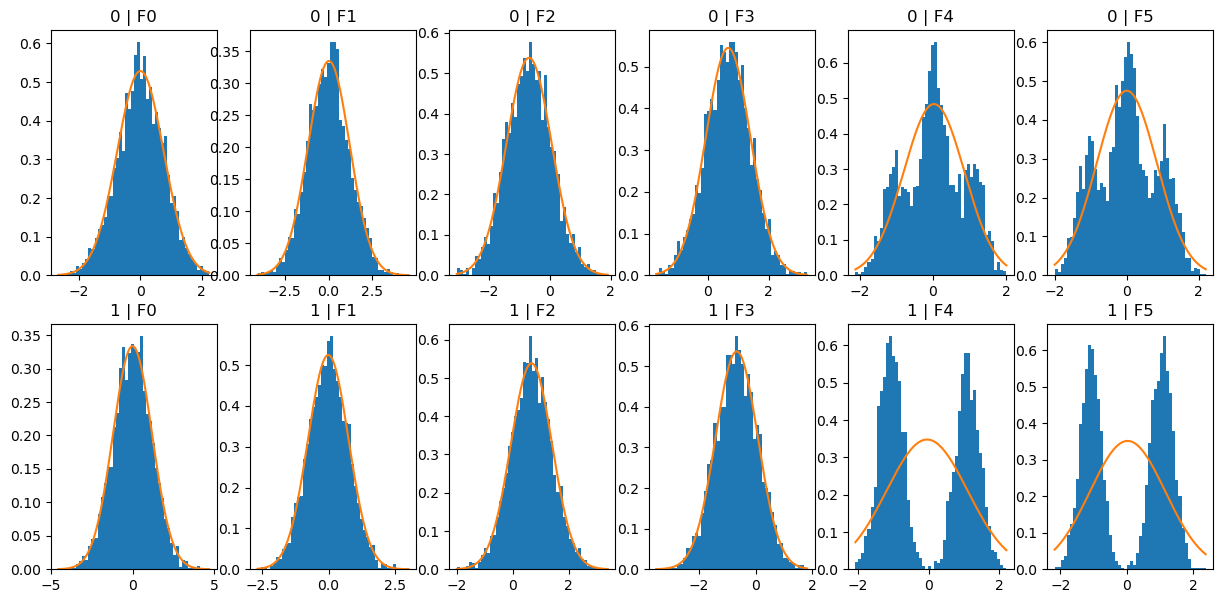

In [ ]:
from utils import vcol, vrow, get_cov, loglikelihood

plt.figure(figsize=(15, 7))

plots_rows = len(labels)
plots_cols = D.shape[0]

for i, l in enumerate(labels):
    class_data = D[:,L==l]

    u_ML = vcol(class_data.mean(1))
    C_ML = get_cov(class_data)

    class_ll = loglikelihood(class_data, u_ML, C_ML)
    print(f"{l} | {class_ll}")


    j=0
    for feature in class_data:
        feature = vrow(feature)
        u_ML = feature.mean(1)
        C_ML = get_cov(feature)
        feature_ll = loglikelihood(feature, u_ML, C_ML)
        print(f"{l} | {feature_names[j]} | {feature_ll}")

        XPlot = np.linspace(feature.min(), feature.max(), 1000)
        logpdf_plot = logpdf_GAU_ND(vrow(XPlot), u_ML, C_ML)

        plt.subplot(plots_rows, plots_cols, i*plots_cols + j + 1)
        plt.hist(feature.ravel(), bins=50, density=True)
        plt.plot(XPlot.ravel(), np.exp(logpdf_plot))

        plt.title(f"{l} | {feature_names[j]}")

        j+=1




In [44]:
from utils import loglikelihood, vcol

u_ML = vcol(D.mean(1))
C_ML = get_cov(D)

total_ll = loglikelihood(D, u_ML, C_ML)
print(total_ll)

-50406.937585730615
